### Preprocessing

In [5]:
import json
import re
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from collections import Counter
from nltk import bigrams
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [6]:
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/cyprienfourcroy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/cyprienfourcroy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
nltk.download("wordnet")    
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/cyprienfourcroy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/cyprienfourcroy/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [9]:
with open("datasets/putin_complete.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

print("HEAD (raw):")
print(df.head(2))
print("\nNumber of rows:", len(df))
print("Columns:", df.columns.tolist())

text_cols = ["transcript_unfiltered", "transcript_filtered"]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df[df["date"].notna()].reset_index(drop=True)

putin_mask = df["transcript_unfiltered"].str.contains(r"\bPutin\b\s*:", regex=True, na=False)
df = df[putin_mask].reset_index(drop=True)

df["transcript_unfiltered"] = df["transcript_unfiltered"].str.replace(
    r"^.*\bPutin\b\s*:\s*", "", regex=True
)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df["text_raw"] = df["transcript_filtered"].where(
    df["transcript_filtered"].str.len() > 0,
    df["transcript_unfiltered"]
)

df["sentences"] = df["text_raw"].apply(
    lambda x: re.split(r"(?<=[.!?])\s+", x.strip()) if x.strip() else []
)

df["sentence_count"] = df["sentences"].apply(len)

def ensure_wordlist(row):
    wl = row.get("wordlist", None)
    if not isinstance(wl, list) or len(wl) == 0:
        return word_tokenize(row["text_raw"])
    return wl

df["tokens_full"] = df.apply(ensure_wordlist, axis=1)

def clean_tokens(tokens):
    return [t.lower() for t in tokens if t.strip() != ""]

df["tokens_clean"] = df["tokens_full"].apply(clean_tokens)

def keep_alpha_tokens(tokens):
    return [t for t in tokens if re.fullmatch(r"[a-z]+", t)]

df["tokens_lexical"] = df["tokens_clean"].apply(keep_alpha_tokens)

stop_words = set(stopwords.words("english"))

df["tokens_nostop"] = df["tokens_lexical"].apply(
    lambda x: [t for t in x if t not in stop_words]
)

lemmatizer = WordNetLemmatizer()

df["tokens_lemma"] = df["tokens_nostop"].apply(
    lambda toks: [lemmatizer.lemmatize(t) for t in toks]
)

df["token_count"] = df["tokens_lexical"].apply(len)
df["unique_tokens"] = df["tokens_lexical"].apply(lambda x: len(set(x)))

df["lexical_diversity"] = df.apply(
    lambda r: r["unique_tokens"] / r["token_count"] if r["token_count"] > 0 else 0,
    axis=1
)

df["avg_sentence_length"] = df.apply(
    lambda r: r["token_count"] / r["sentence_count"] if r["sentence_count"] > 0 else 0,
    axis=1
)

def rhetorical_features(text):
    return {
        "exclamation_count": text.count("!"),
        "question_count": text.count("?"),
        "ellipsis_count": text.count("...")
    }

rhet_feats = df["text_raw"].apply(rhetorical_features)
rhet_df = pd.DataFrame(list(rhet_feats))
df = pd.concat([df, rhet_df], axis=1)

HEAD (raw):
                  date persons  \
0  1999-12-31T00:01:00      []   
1  1999-12-31T00:02:00      []   

                               transcript_unfiltered  kremlin_id  \
0  Vladimir Putin: Dear friends, On New Year’s Ev...     22280.0   
1  Vladimir Putin: Good afternoon, distinguished ...     22326.0   

                 place                                              title  \
0  The Kremlin, Moscow  New Year Address by Acting President Vladimir ...   
1  The Kremlin, Moscow  Address at an expanded meeting of the Russian ...   

  teaser tags                                transcript_filtered  \
0          []  Dear friends, On New Year’s Eve, my family and...   
1          []  Good afternoon, distinguished colleagues. This...   

                                            wordlist  
0  [dear, friend, ,, on, New, Year, ’s, Eve, ,, m...  
1  [good, afternoon, ,, distinguished, colleague,...  

Number of rows: 9838
Columns: ['date', 'persons', 'transcript_unfiltered', 'k

In [9]:
df.to_json(
    "datasets/putin_complete_cleaned.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("\nSaved cleaned dataset: putin_complete_cleaned.json")


Saved cleaned dataset: putin_complete_cleaned.json


In [10]:
with open("datasets/putin_complete_cleaned.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

### Comparaison

### 1. How does the narrative toward Poland differ from that toward Germany? (Sentiment analysis, RoBERTa)
 

In [7]:
mask_pl = df["transcript_filtered"].str.contains(r"\bPoland\b", case=False, na=False)
mask_de = df["transcript_filtered"].str.contains(r"\bGermany\b", case=False, na=False)

df_pl = df[mask_pl]
df_de = df[mask_de]


In [8]:
df_pl.shape

(144, 27)

In [9]:
df_de.shape

(473, 27)

We are going to use sentiment_roberta_large_english which has a legacy format from HuggingFace

In [ ]:
# # Model weights (large ~1.3–1.4GB)
# curl -L --fail --retry 10 --retry-delay 2 -C - \
#   -o pytorch_model.bin \
#   "https://huggingface.co/siebert/sentiment-roberta-large-english/resolve/main/pytorch_model.bin"

# # Model config
# curl -L --fail --retry 10 --retry-delay 2 \
#   -o config.json \
#   "https://huggingface.co/siebert/sentiment-roberta-large-english/resolve/main/config.json"

# # Tokenizer files (RoBERTa BPE)
# curl -L --fail --retry 10 --retry-delay 2 \
#   -o vocab.json \
#   "https://huggingface.co/siebert/sentiment-roberta-large-english/resolve/main/vocab.json"

# curl -L --fail --retry 10 --retry-delay 2 \
#   -o merges.txt \
#   "https://huggingface.co/siebert/sentiment-roberta-large-english/resolve/main/merges.txt"

# # Tokenizer metadata
# curl -L --fail --retry 10 --retry-delay 2 \
#   -o tokenizer_config.json \
#   "https://huggingface.co/siebert/sentiment-roberta-large-english/resolve/main/tokenizer_config.json"

# curl -L --fail --retry 10 --retry-delay 2 \
#   -o special_tokens_map.json \
#   "https://huggingface.co/siebert/sentiment-roberta-large-english/resolve/main/special_tokens_map.json"



In [11]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_dir = "./sentiment_roberta_large"

tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

print("Loaded labels:", model.config.id2label)


Loaded labels: {0: 'NEGATIVE', 1: 'POSITIVE'}


In [12]:
import torch

text = "Germany is acting irresponsibly, while Poland remains pragmatic."

enc = tokenizer(text, return_tensors="pt", truncation=True)
with torch.no_grad():
    logits = model(**enc).logits
probs = torch.softmax(logits, dim=-1)[0].tolist()

print("probs:", probs)
print("pred:", model.config.id2label[int(torch.argmax(logits))])


probs: [0.9968913197517395, 0.00310869375243783]
pred: NEGATIVE


In [13]:


df_sent = df.explode("sentences").rename(columns={"sentences": "sentence"})
df_sent = df_sent[df_sent["sentence"].str.strip() != ""].reset_index(drop=True)

pl_sent = df_sent[df_sent["sentence"].str.contains(r"\bPoland\b", case=False, na=False)].copy()
de_sent = df_sent[df_sent["sentence"].str.contains(r"\bGermany\b", case=False, na=False)].copy()

print("Poland sentences:", len(pl_sent))
print("Germany sentences:", len(de_sent))


Poland sentences: 364
Germany sentences: 1486


In [14]:
tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
model.eval()


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=Tru

In [15]:
import torch
import numpy as np

def batched_sentiment(texts, tokenizer, model, batch_size=16, max_length=256):
    all_pos_probs = []
    all_labels = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        )

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)

        # model.config.id2label = {0: 'NEGATIVE', 1: 'POSITIVE'}
        pos_index = [k for k,v in model.config.id2label.items() if v == "POSITIVE"][0]

        pos_probs = probs[:, pos_index].cpu().numpy()
        labels = probs.argmax(dim=-1).cpu().numpy()

        all_pos_probs.extend(pos_probs.tolist())
        all_labels.extend(labels.tolist())

    return np.array(all_pos_probs), np.array(all_labels)


In [16]:
pl_texts = pl_sent["sentence"].tolist()
de_texts = de_sent["sentence"].tolist()

pl_pos_probs, pl_labels = batched_sentiment(pl_texts, tokenizer, model, batch_size=16)
de_pos_probs, de_labels = batched_sentiment(de_texts, tokenizer, model, batch_size=16)

pl_sent["pos_prob"] = pl_pos_probs
pl_sent["label"] = pl_labels

de_sent["pos_prob"] = de_pos_probs
de_sent["label"] = de_labels


In [17]:
def sentiment_proportions(df_local):
    total = len(df_local)
    pos = (df_local["label"] == 1).sum()
    neg = (df_local["label"] == 0).sum()
    return {
        "positive": pos / total if total > 0 else 0,
        "negative": neg / total if total > 0 else 0,
        "count": total
    }

pl_props = sentiment_proportions(pl_sent)
de_props = sentiment_proportions(de_sent)

print("Poland sentiment distribution:", pl_props)
print("Germany sentiment distribution:", de_props)


Poland sentiment distribution: {'positive': np.float64(0.6318681318681318), 'negative': np.float64(0.36813186813186816), 'count': 364}
Germany sentiment distribution: {'positive': np.float64(0.8055181695827726), 'negative': np.float64(0.19448183041722747), 'count': 1486}


In [18]:
import matplotlib.pyplot as plt
import numpy as np


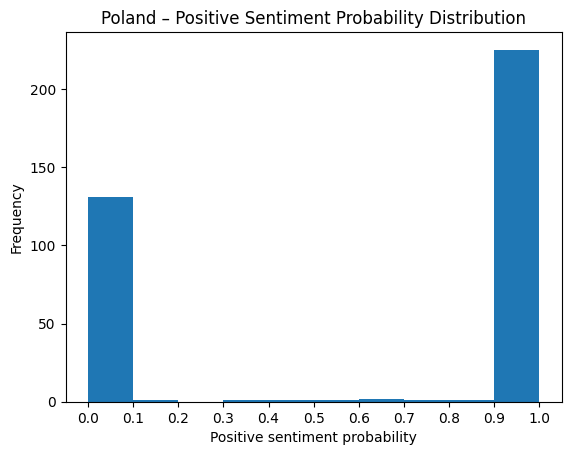

In [20]:
bins = np.arange(0, 1.1, 0.1)

plt.figure()
plt.hist(pl_sent["pos_prob"], bins=bins)
plt.title("Poland – Positive Sentiment Probability Distribution")
plt.xlabel("Positive sentiment probability")
plt.ylabel("Frequency")
plt.xticks(bins)
plt.show()



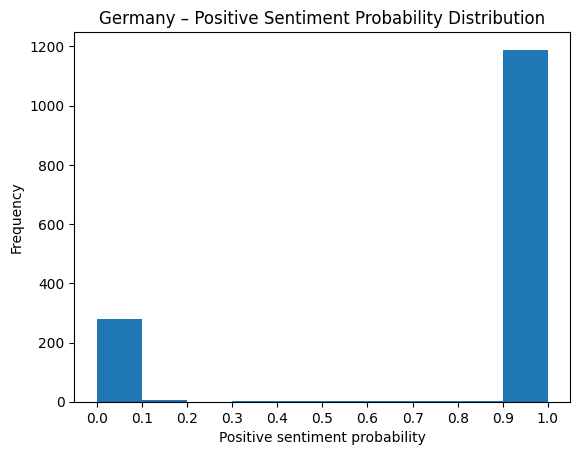

In [21]:
plt.figure()
plt.hist(de_sent["pos_prob"], bins=bins)
plt.title("Germany – Positive Sentiment Probability Distribution")
plt.xlabel("Positive sentiment probability")
plt.ylabel("Frequency")
plt.xticks(bins)
plt.show()
